# Zero-Crossing Detection

## FMU using Explicit Euler Integration

- Explicit Euler allows for FMI 2.0 CS FMU to use `fmu.getFMUState()` and `fmu.setFMUState(state)`.
- This enables saving and restoring FMU states for zero-crossing detection.
- When a zero-crossing after performing a step is detected, the FMU state before the step is restored.
- A bisection method is then used to find the zero-crossing time and state.
- After finding the crossing point, the FMU is reinitialized with the new state (with swapped velocity in this case) to continue the simulation.

**Limitations:**
- This approach is specific to FMUs that support state saving/restoring.
- This approach in not applicable for FMUs using CVODE integrators, as they maintain an internal state that cannot be easily manipulated.
- Explicit Euler is less accurate and stable compared to more advanced integrators like CVODE.
- A reduced global step size `dt` is neceassary to ensure a stable simulation and accurate zero-crossing detection within the maximum number of bisection iterations.

In [80]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

In [ ]:
from OMPython import ModelicaSystem
from shutil import move

pkg_file = Path.cwd().parent / 'Modelica/ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.Pendulum'
solver_euler = "euler"
solver_cvode = "cvode"
model_euler = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:{solver_euler}")
model_cvode = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:{solver_cvode}")
model_euler.buildModel()
model_cvode.buildModel()

fmu_path_euler = model_euler.convertMo2Fmu(fmuType='cs')
fmu_path_cvode = model_cvode.convertMo2Fmu(fmuType='cs')

dest_path_euler = Path.cwd() / 'FMUs/Pendulum_Euler.fmu'
move(fmu_path_euler, dest_path_euler)

dest_path_cvode = Path.cwd() / 'FMUs/Pendulum_Cvode.fmu'
move(fmu_path_cvode, dest_path_cvode)

print(f"FMU saved to: {dest_path_euler}")
print(f"FMU saved to: {dest_path_cvode}")


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.



FMU saved to: /home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Pendulum_Euler.fmu
FMU saved to: /home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Pendulum_Cvode.fmu


--------------------------

In [149]:
# Test Hybrid Capabilities of Modelica System
model = model_cvode

# Set initial conditions
model.setParameters("q0=0.3", "omega0=0.0")
model.buildModel()
model.getSimulationOptions()
model.simulate()

model.setSimulationOptions(["startTime=0", "stopTime=10"])
model.simulate()

path = model.convertMo2Fmu(fmuType='cs')
comp = FMUComponent("Pendulum_Cvode", path)

comp.initialize(t0=0.0)
comp.direct_feedthrough


LOG_STDOUT        | warning | Start or stop time was overwritten, but no new integrator step size was provided.
|                 | info    | | Re-calculating step size for 500 intervals.
|                 | |       | | Add `stepSize=<value>` to `-override=` or override file to silence this warning.
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
LOG_STDOUT        | warning | Start or stop time was overwritten, but no new integrator step size was provided.
|                 | info    | | Re-calculating step size for 500 intervals.
|                 | |       | | Add `stepSize=<value>` to `-override=` or override file to silence this warning.
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LO

{'alpha': ['torque'], 'omega': [], 'q': []}

----------------------

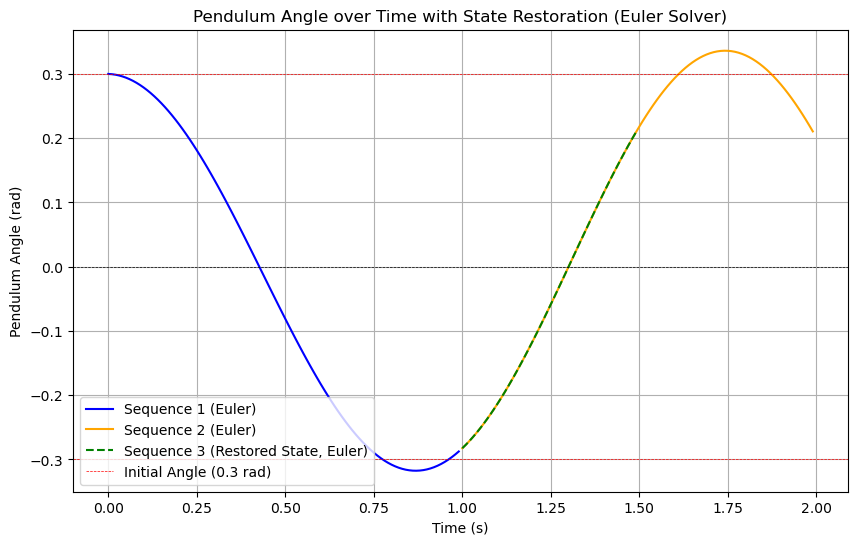

In [121]:
pendulum_euler = FMUComponent(name="Pendulum_Euler", fmu_path=str(dest_path_euler))
pendulum_euler.set_parameters(q0=0.3)
pendulum_euler.initialize(0.0)
fmu_euler = pendulum_euler._instance

vars = pendulum_euler._md_vars
omega0_vr = vars.get('omega0').valueReference
q0_vr = vars.get('q0').valueReference
omega_vr = vars.get('omega').valueReference
q_vr = vars.get('q').valueReference

t_vals_1 = []
t_vals_2 = []
t_vals_3 = []
q_vals_1 = []
q_vals_2 = []
q_vals_3 = []

# Sequence 1
t = 0.0
dt = 0.01
end_time = 1.0

while t < end_time:
    fmu_euler.doStep(t, dt)
    q = fmu_euler.getReal([q_vr])[0]
    t_vals_1.append(t)
    q_vals_1.append(q)
    t += dt

state_1s = fmu_euler.getFMUState()
t_state = t

# Sequence 2
end_time = 2.0
while t < end_time:
    fmu_euler.doStep(t, dt)
    q = fmu_euler.getReal([q_vr])[0]
    t_vals_2.append(t)
    q_vals_2.append(q)
    t += dt

# Restore state from end of sequence 1
fmu_euler.setFMUState(state_1s)
t = t_state
end_time = 1.5
while t < end_time:
    fmu_euler.doStep(t, dt)
    q = fmu_euler.getReal([q_vr])[0]
    t_vals_3.append(t)
    q_vals_3.append(q)
    t += dt

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t_vals_1, q_vals_1, label='Sequence 1 (Euler)', color='blue')
plt.plot(t_vals_2, q_vals_2, label='Sequence 2 (Euler)', color='orange')
plt.plot(t_vals_3, q_vals_3, label='Sequence 3 (Restored State, Euler)', color='green', linestyle='--')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(0.3, color='red', linewidth=0.5, linestyle='--', label='Initial Angle (0.3 rad)')
plt.axhline(-0.3, color='red', linewidth=0.5, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.title('Pendulum Angle over Time with State Restoration (Euler Solver)')
plt.grid()
plt.legend(loc='lower left')
plt.show()

In [134]:
pendulum_cvode = FMUComponent(name="Pendulum_Cvode", fmu_path=str(dest_path_cvode))
pendulum_cvode.set_parameters(q0=0.3)
pendulum_cvode.initialize(0.0)
fmu_cvode = pendulum_cvode._instance

vars = pendulum_cvode._md_vars
omega0_vr = vars.get('omega0').valueReference
q0_vr = vars.get('q0').valueReference
omega_vr = vars.get('omega').valueReference
q_vr = vars.get('q').valueReference

t_vals_1 = []
t_vals_2 = []
t_vals_3 = []
q_vals_1 = []
q_vals_2 = []
q_vals_3 = []

# Sequence 1
t = 0.0
dt = 0.01
end_time = 1.0

while t < end_time:
    fmu_cvode.doStep(t, dt)
    q = fmu_cvode.getReal([q_vr])[0]
    t_vals_1.append(t)
    q_vals_1.append(q)
    t += dt

state_1s = fmu_cvode.getFMUState()
t_state = t

# Sequence 2
end_time = 2.0
while t < end_time:
    fmu_cvode.doStep(t, dt)
    q = fmu_cvode.getReal([q_vr])[0]
    t_vals_2.append(t)
    q_vals_2.append(q)
    t += dt

# Restore state from end of sequence 1
fmu_cvode.setFMUState(state_1s)
# q0 = fmu_cvode.getReal([q_vr])[0]
# omega0 = fmu_cvode.getReal([omega_vr])[0]
# fmu_cvode.reset()
# fmu_cvode.instantiate()
# fmu_cvode.setupExperiment(startTime=t_state)
# fmu_cvode.enterInitializationMode()
# fmu_cvode.setReal([q0_vr, omega0_vr], [q0, omega0])
# fmu_cvode.exitInitializationMode()

t = t_state
end_time = 1.5
while t < end_time:
    fmu_cvode.doStep(t, dt)
    q = fmu_cvode.getReal([q_vr])[0]
    t_vals_3.append(t)
    q_vals_3.append(q)
    t += dt

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t_vals_1, q_vals_1, label='Sequence 1 (Euler)', color='blue')
plt.plot(t_vals_2, q_vals_2, label='Sequence 2 (Euler)', color='orange')
plt.plot(t_vals_3, q_vals_3, label='Sequence 3 (Restored State, Euler)', color='green', linestyle='--')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(0.3, color='red', linewidth=0.5, linestyle='--', label='Initial Angle (0.3 rad)')
plt.axhline(-0.3, color='red', linewidth=0.5, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.title('Pendulum Angle over Time with State Restoration (Euler Solver)')
plt.grid()
plt.legend(loc='lower left')
plt.show()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


FMICallException: fmi2DoStep failed with status 4 (fatal).

In [125]:
pendulum = FMUComponent(fmu_path=dest_path_euler, name='pendulum')
t = 0.0
pendulum.set_parameters(q0=np.deg2rad(20))
pendulum.initialize(t0=t)
fmu = pendulum._instance
vars = pendulum._md_vars
omega0_vr = vars.get('omega0').valueReference
q0_vr = vars.get('q0').valueReference
omega_vr = vars.get('omega').valueReference
q_vr = vars.get('q').valueReference

In [126]:
def find_zero_crossing(fmu, q_vr, t_start, dt_initial, tolerance=1e-6, max_iterations=20):
    # Save initial state
    state_before = fmu.getFMUState()
    q_before = fmu.getReal([q_vr])[0]
    
    # Take initial step
    fmu.doStep(currentCommunicationPoint=t_start, communicationStepSize=dt_initial)
    q_after = fmu.getReal([q_vr])[0]
    
    if q_before * q_after >= 0:
        # No sign change, no crossing
        fmu.freeFMUState(state_before)
        return None, None, False
    
    # Bisection to find exact crossing
    t_left = t_start
    dt = dt_initial
    
    for iteration in range(max_iterations):
        dt = dt / 2
        t_right = t_left + dt
        
        # Restore state and step to t_right
        fmu.setFMUState(state_before)
        fmu.doStep(currentCommunicationPoint=t_left, communicationStepSize=dt)
        q_mid = fmu.getReal([q_vr])[0]
        
        print(f"  Iteration {iteration+1}: t={t_right:.6f}s, q={np.rad2deg(q_mid):.6f}deg, dt={dt:.6e}s")
        
        # Check convergence
        if abs(q_mid) < tolerance:
            fmu.freeFMUState(state_before)
            return t_right, q_mid, True
        
        # Update interval
        if q_before * q_mid < 0:
            # Crossing in left half
            t_right = t_right
        else:
            # Crossing in right half
            t_left = t_right
            q_before = q_mid
            # Save new state at left boundary
            fmu.freeFMUState(state_before)
            state_before = fmu.getFMUState()
    
    fmu.freeFMUState(state_before)
    return t_left + dt, q_mid, False

In [127]:
t = 0.0
dt = 0.001
t_end = 2.0

t_vals = []
q_vals = []
omega_vals = []
event_times = []

# Initialize with first point
q_prev = fmu.getReal([q_vr])[0]
t_vals.append(t)
q_vals.append(q_prev)
omega_vals.append(fmu.getReal([omega_vr])[0])

while t < t_end:
    # Save state before step
    state = fmu.getFMUState()
    
    # Take a step
    fmu.doStep(currentCommunicationPoint=t, communicationStepSize=dt)
    t_new = t + dt
    q_new = fmu.getReal([q_vr])[0]
    omega_new = fmu.getReal([omega_vr])[0]
    
    # Check for zero-crossing (sign change from + to -)
    if q_prev > 0 and q_new < 0:
        print(f"\nZero-crossing detected between t={t:.4f}s and t={t_new:.4f}s")
        print(f"   q changed from {np.rad2deg(q_prev):.6f}° to {np.rad2deg(q_new):.6f}°")
        
        # Restore state and find exact crossing
        fmu.setFMUState(state)
        t_event, q_cross, converged = find_zero_crossing(
            fmu, q_vr, t, dt, tolerance=1e-6, max_iterations=20
        )
        
        print(f"Converged: t_event={t_event:.6f}s, q={np.rad2deg(q_cross):.6f}°")
        event_times.append(t_event)
            
        # Store crossing point
        t_vals.append(t_event)
        q_vals.append(q_cross)
        omega = fmu.getReal([omega_vr])[0]
        omega_vals.append(omega)
            
        # Continue from crossing point
        t = t_event
        q_prev = q_cross

        # Reinitialize FMU at crossing point with swapped velocity
        fmu.instantiate()
        fmu.setupExperiment(startTime=t)
        fmu.enterInitializationMode()
        fmu.setReal([q0_vr], [q_cross])
        fmu.setReal([omega0_vr], [-0.8*omega])
        fmu.exitInitializationMode()

        fmu.freeFMUState(state)
        
    else:
        # Normal step, store data
        t_vals.append(t_new)
        q_vals.append(q_new)
        omega_vals.append(omega_new)
        t = t_new
        q_prev = q_new
        fmu.freeFMUState(state)

print(f"\n{'='*60}")
print(f"Zero-crossing times: {event_times}")
print(f"{'='*60}")


Zero-crossing detected between t=0.4370s and t=0.4380s
   q changed from 0.016190° to -0.056052°
  Iteration 1: t=0.437500s, q=-0.019931deg, dt=5.000000e-04s
  Iteration 2: t=0.437250s, q=-0.001871deg, dt=2.500000e-04s
  Iteration 3: t=0.437125s, q=0.007159deg, dt=1.250000e-04s
  Iteration 4: t=0.437188s, q=0.002644deg, dt=6.250000e-05s
  Iteration 5: t=0.437219s, q=0.000387deg, dt=3.125000e-05s
  Iteration 6: t=0.437234s, q=-0.000742deg, dt=1.562500e-05s
  Iteration 7: t=0.437227s, q=-0.000178deg, dt=7.812500e-06s
  Iteration 8: t=0.437223s, q=0.000105deg, dt=3.906250e-06s
  Iteration 9: t=0.437225s, q=-0.000037deg, dt=1.953125e-06s
Converged: t_event=0.437225s, q=-0.000037°

Zero-crossing detected between t=1.3092s and t=1.3102s
   q changed from 0.003267° to -0.054853°
  Iteration 1: t=1.309725s, q=-0.025793deg, dt=5.000000e-04s
  Iteration 2: t=1.309475s, q=-0.011263deg, dt=2.500000e-04s
  Iteration 3: t=1.309350s, q=-0.003998deg, dt=1.250000e-04s
  Iteration 4: t=1.309287s, q=-0.

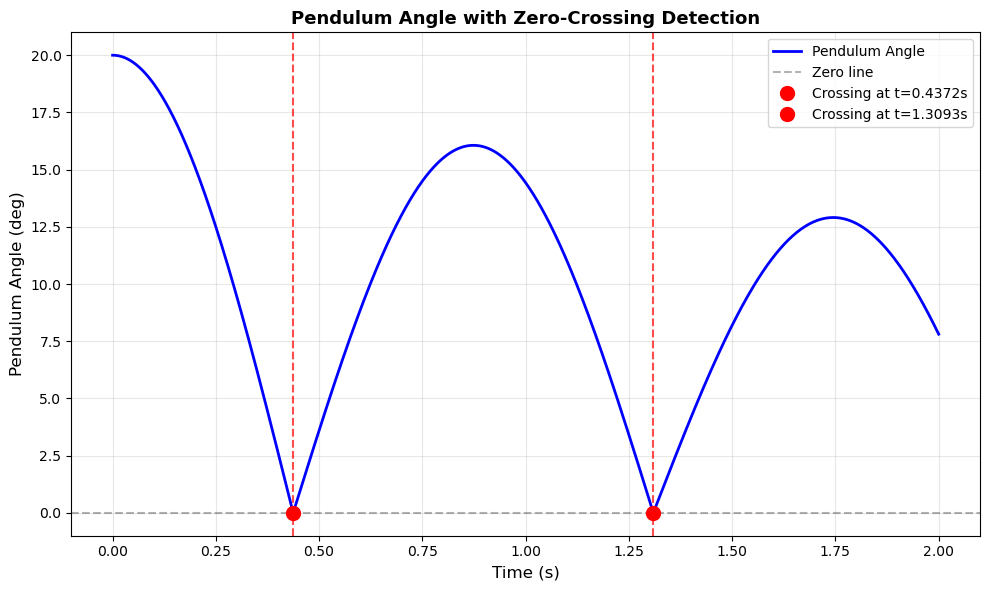

In [128]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_vals), 'b-', linewidth=2, label='Pendulum Angle')
plt.axhline(0, color='k', linestyle='--', alpha=0.3, label='Zero line')

# Mark zero-crossings
for t_event in event_times:
    plt.axvline(t_event, color='red', linestyle='--', alpha=0.7)
    plt.plot(t_event, 0, 'ro', markersize=10, label=f'Crossing at t={t_event:.4f}s')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Pendulum Angle (deg)', fontsize=12)
plt.title('Pendulum Angle with Zero-Crossing Detection', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

------------------------

## FMU using CVODE Integration
- CVODE does not support `fmu.getFMUState()` and `fmu.setFMUState(state)`, making state restoration impossible.
- For simple FMUs, the state needs to be made manually accesible via model variables. 
- Furthermore, one needs to reinitialize the FMU at the crossing point by setting the model variables directly.
- This approach is more error-prone and may not work for complex models with many states or algebraic loops.
- The FMU is reinitialized at the crossing point with the new state (with swapped velocity in this case) to continue the simulation.

In [129]:
pendulum = FMUComponent(fmu_path=dest_path_cvode, name='pendulum')
t = 0.0
pendulum.set_parameters(q0=np.deg2rad(20))
pendulum.initialize(t0=t)
fmu = pendulum._instance
vars = pendulum._md_vars
omega0_vr = vars.get('omega0').valueReference
q0_vr = vars.get('q0').valueReference
omega_vr = vars.get('omega').valueReference
q_vr = vars.get('q').valueReference

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [130]:
def find_zero_crossing(fmu, q_vr, t_start, dt_initial, tolerance=1e-6, max_iterations=20):
    # Svae the state of the FMU pendulum before the step
    t_before = t_start
    q_before = fmu.getReal([q_vr])[0]
    omega_before = fmu.getReal([omega_vr])[0]

    t_mid_values = []
    q_mid_values = []
    
    # Take initial step
    fmu.doStep(currentCommunicationPoint=t_start, communicationStepSize=dt_initial)
    q_after = fmu.getReal([q_vr])[0]
    
    # Check if crossing occurred    
    if q_before * q_after >= 0:
        # No sign change, no crossing
        return None, None, False, t_mid_values, q_mid_values
    
    # Bisection to find exact crossing
    t_left = t_start
    t_right = t_start + dt_initial
    dt = dt_initial
    
    for iteration in range(max_iterations):
        dt = dt / 2
        t_mid = t_left + dt
        
        # Restore state and step to midpoint
        fmu.instantiate()
        fmu.setupExperiment(startTime=t_left)
        fmu.enterInitializationMode()
        fmu.setReal([q0_vr], [q_before])
        fmu.setReal([omega0_vr], [omega_before])
        fmu.exitInitializationMode()
        fmu.doStep(currentCommunicationPoint=t_left, communicationStepSize=dt)
        q_mid = fmu.getReal([q_vr])[0]

        if q_mid > 0:
            t_mid_values.append(t_mid)
            q_mid_values.append(q_mid)
        
        print(f"  Iteration {iteration+1}: t={t_mid:.6f}s, q={np.rad2deg(q_mid):.6f}deg, dt={dt:.6e}s")
        
        # Check convergence
        if abs(q_mid) < tolerance:
            return t_mid, q_mid, True, t_mid_values, q_mid_values
        
        # Update interval
        if q_before * q_mid < 0:
            # Crossing in left half
            t_right = t_mid

        else:
            # Crossing in right half
            t_left = t_mid
            q_before = q_mid
            # Save new state at left boundary
            t_before = t_mid
            q_before = q_mid
            omega_before = fmu.getReal([omega_vr])[0]
    
    return t_left + dt, q_mid, False, t_mid_values, q_mid_values

In [131]:
t = 0.0
dt = 0.01
t_end = 2.0

t_vals = []
q_vals = []
omega_vals = []
event_times = []

# Initialize with first point
q_prev = fmu.getReal([q_vr])[0]
t_vals.append(t)
q_vals.append(q_prev)
omega_vals.append(fmu.getReal([omega_vr])[0])

while t < t_end:
    # Save state before step
    state = fmu.getFMUState()
    
    # Take a step
    fmu.doStep(currentCommunicationPoint=t, communicationStepSize=dt)
    t_new = t + dt
    q_new = fmu.getReal([q_vr])[0]
    omega_new = fmu.getReal([omega_vr])[0]
    
    # Check for zero-crossing (sign change from + to -)
    if q_prev > 0 and q_new < 0:
        print(f"\n🔍 Zero-crossing detected between t={t:.4f}s and t={t_new:.4f}s")
        print(f"   q changed from {np.rad2deg(q_prev):.2f}° to {np.rad2deg(q_new):.2f}°")
        
        # Restore state and find exact crossing
        fmu.setFMUState(state)
        t_event, q_cross, converged, t_mid_values, q_mid_values = find_zero_crossing(
            fmu, q_vr, t, dt, tolerance=1e-6, max_iterations=20
        )
        
        if converged:
            print(f"✅ Converged: t_cross={t_event:.6f}s, q={np.rad2deg(q_cross):.6f}°")
            event_times.append(t_event)
            
            # Store crossing point
            t_vals.extend(t_mid_values)
            q_vals.extend(q_mid_values)
            omega = fmu.getReal([omega_vr])[0]
            omega_vals.append(omega)
            
            # Continue from crossing point
            t = t_event
            q_prev = q_cross

            # Reinitialize FMU at crossing point with swapped velocity
            fmu.instantiate()
            fmu.setupExperiment(startTime=t)
            fmu.enterInitializationMode()
            fmu.setReal([q0_vr], [q_cross])
            fmu.setReal([omega0_vr], [-0.8*omega])
            fmu.exitInitializationMode()
        else:
            print(f"⚠️  Did not converge, continuing...")
            t = t_new
            q_prev = q_new
            t_vals.append(t_new)
            q_vals.append(q_new)
            omega_vals.append(omega_new)
        
        fmu.freeFMUState(state)
        
        # For demonstration, break after first crossing
        #break
    else:
        # Normal step, store data
        t_vals.append(t_new)
        q_vals.append(q_new)
        omega_vals.append(omega_new)
        t = t_new
        q_prev = q_new
        fmu.freeFMUState(state)

print(f"\n{'='*60}")
print(f"Zero-crossing times: {event_times}")
print(f"{'='*60}")


🔍 Zero-crossing detected between t=0.4300s and t=0.4400s
   q changed from 0.52° to -0.20°
  Iteration 1: t=0.435000s, q=0.159475deg, dt=5.000000e-03s
  Iteration 2: t=0.437500s, q=-0.020623deg, dt=2.500000e-03s
  Iteration 3: t=0.436250s, q=0.069427deg, dt=1.250000e-03s
  Iteration 4: t=0.436875s, q=0.024402deg, dt=6.250000e-04s
  Iteration 5: t=0.437188s, q=0.001889deg, dt=3.125000e-04s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER  

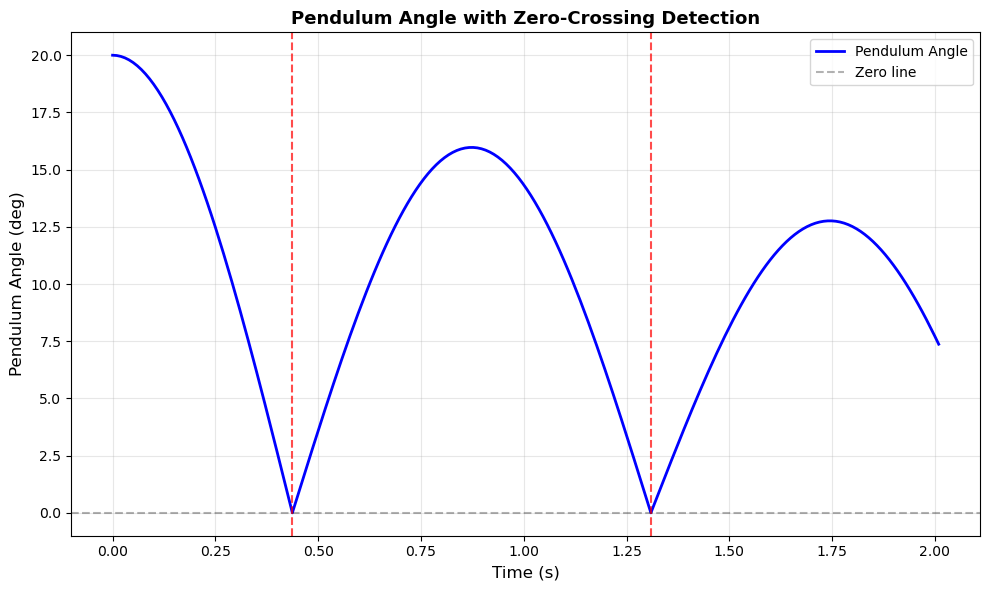

In [132]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_vals), 'b-', linewidth=2, label='Pendulum Angle')
plt.axhline(0, color='k', linestyle='--', alpha=0.3, label='Zero line')

# Mark zero-crossings
for t_event in event_times:
    plt.axvline(t_event, color='red', linestyle='--', alpha=0.7)
    #plt.plot(t_cross, 0, 'ro', markersize=10, label=f'Crossing at t={t_cross:.4f}s')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Pendulum Angle (deg)', fontsize=12)
plt.title('Pendulum Angle with Zero-Crossing Detection', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

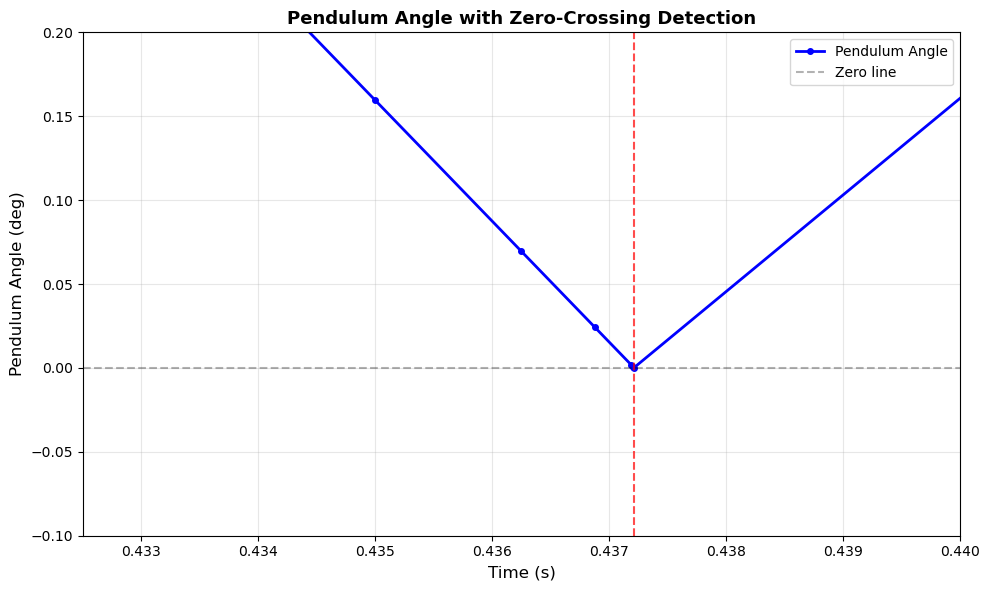

In [133]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_vals), 'b-', linewidth=2, label='Pendulum Angle', marker='o', markersize=4)
plt.axhline(0, color='k', linestyle='--', alpha=0.3, label='Zero line')

# Mark zero-crossings
for t_event in event_times:
    plt.axvline(t_event, color='red', linestyle='--', alpha=0.7)
    #plt.plot(t_cross, 0, 'ro', markersize=10, label=f'Crossing at t={t_cross:.4f}s')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Pendulum Angle (deg)', fontsize=12)
plt.xlim(0.4325, 0.44)
plt.ylim(-0.1, 0.2)
plt.title('Pendulum Angle with Zero-Crossing Detection', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

------------------

In [63]:
pendulum = FMUComponent(fmu_path=dest_path, name='pendulum')
pendulum.set_parameters(q0=np.deg2rad(20))
pendulum.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [64]:
def get_event_indictor(self: FMUComponent):
    """
    Returns the event indicator for the pendulum hitting the wall at q = 0.
    The event is triggered when the pendulum angle q crosses zero from positive to negative.
    """
    q_wall = 0.0
    q_pendulum = self.get_outputs()['q']
    direction = 1 # approaching from q > q_wall and omega < 0
    return direction * (q_pendulum - q_wall)

In [65]:
pendulum.get_event_indictor = get_event_indictor

In [67]:
pendulum.get_event_indictor(pendulum)

<Quantity(0.34906585, 'radian')>

In [68]:
t = 0.0
t_end = 2
dt = 0.01

while t < t_end:
    ind_before = pendulum.get_event_indictor(pendulum)
    pendulum.do_step(t=t, dt=dt)
    ind_after = pendulum.get_event_indictor(pendulum)
    if ind_before > 0 and ind_after < 0:
        print(f"Zero-crossing detected at t={t:.4f}s: q changed from {np.rad2deg(ind_before):.2f}° to {np.rad2deg(ind_after):.2f}°")
    t += dt

Zero-crossing detected at t=0.4300s: q changed from 0.52 degree° to -0.20 degree°


In [69]:
class Event:
    def __init__(self, name: str, indicator: callable):
        self.name = name
        self.indicator = indicator

In [71]:
hit_event = Event(name="PendulumWallHit", indicator=get_event_indictor)

In [72]:
hit_event.indicator(pendulum)

<Quantity(0.216694618, 'radian')>